In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import STL

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [2]:
data = pd.read_csv("../../Downloads/iex_dam_feb_mar_2026.csv")

In [3]:
# conforming type
data["period_start"] = pd.to_datetime(data["period_start"])
data["period_enum"] = data["period_start"].dt.hour * 4 + data["period_start"].dt.minute // 15 + 1
data["weekday_enum"] = data["period_start"].dt.weekday + 1

In [4]:
data["pb_lag1d"] = data["purchase_bid"].shift(96)
data["sb_lag1d"] = data["sell_bid"].shift(96)
data["pb_lag2d"] = data["purchase_bid"].shift(192)
data["sb_lag2d"] = data["sell_bid"].shift(192)

data['target_diff'] = data['purchase_bid']

data_clean = data.dropna()

print(f"New feature count: {len(data_clean.columns)}")
data_clean.head()

New feature count: 16


,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume,period_enum,weekday_enum,pb_lag1d,sb_lag1d,pb_lag2d,sb_lag2d,ucv,ucv_lag1d,target_diff
192,2026-02-03 00:00:00,00:00 - 00:15,11816.4,30030.2,7074.50,2440.64,7074.50,1,2,12380.9,29543.7,11446.6,30678.9,4741.90,5155.00,11816.4
193,2026-02-03 00:15:00,00:15 - 00:30,12001.8,32385.0,7265.10,2440.58,7265.10,2,2,13084.5,31204.4,12066.8,32484.0,4736.70,5881.35,12001.8
194,2026-02-03 00:30:00,00:30 - 00:45,13033.6,33866.9,7615.70,2500.15,7615.70,3,2,13621.6,32825.1,12510.9,34476.2,5417.90,6311.57,13033.6
195,2026-02-03 00:45:00,00:45 - 01:00,13322.1,35093.5,7674.00,2510.67,7674.00,4,2,13675.3,34558.3,12502.6,36013.3,5648.10,5865.91,13322.1
196,2026-02-03 01:00:00,01:00 - 01:15,13459.3,35489.0,7996.69,2500.81,7996.69,5,2,13720.1,35119.1,12423.8,36515.8,5462.61,5817.89,13459.3


## LightGBM

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[770]	train's rmse: 1243.57	valid's rmse: 2385.91

--- Model Performance ---
MAE: 2069.90
RMSE: 5692588.74


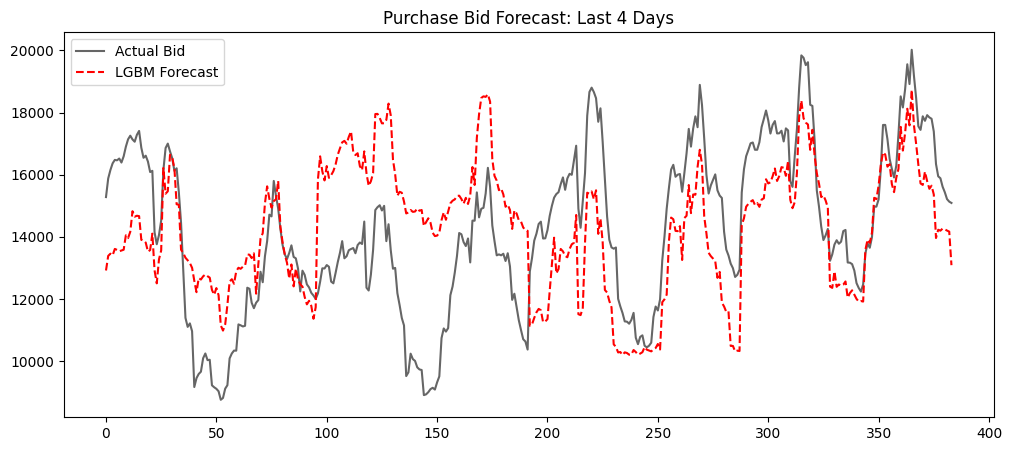

In [129]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Define Features and Target
# Using the lags you created in cell [5] plus your enums
features = [
    'period_enum', 'weekday_enum', 
    'pb_lag1d', 'pb_lag2d'
    # 'pb_lag1d_plus1', 'pb_lag1d_plus2', 'pb_lag1d_minus1', 'pb_lag1d_minus2',
    # 'sb_lag1d',
    # 'sb_lag1d_plus1', 'sb_lag1d_plus2', 'sb_lag1d_minus1', 'sb_lag1d_minus2'
]
target = 'purchase_bid'

X = data_clean[features]
y = data_clean[target]

# 2. Time-Series Split (Don't use random_split for time data!)
# We'll take the last 4 days (96 * 4) as our test set
test_size = 96*4 
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

# 3. Create LightGBM Datasets
# Explicitly telling LightGBM which columns are categorical
cat_features = ['period_enum']#, 'weekday_enum']
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_features)

# 4. Set Parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.005,
    'num_leaves': 64,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1
}

# 5. Train the Model
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 6. Predict and Evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f"\n--- Model Performance ---")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# 7. Quick Visualization
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Bid', color='black', alpha=0.6)
plt.plot(y_pred, label='LGBM Forecast', color='red', linestyle='--')
plt.title('Purchase Bid Forecast: Last 4 Days')
plt.legend()
plt.show()

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_92223/2794048663.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


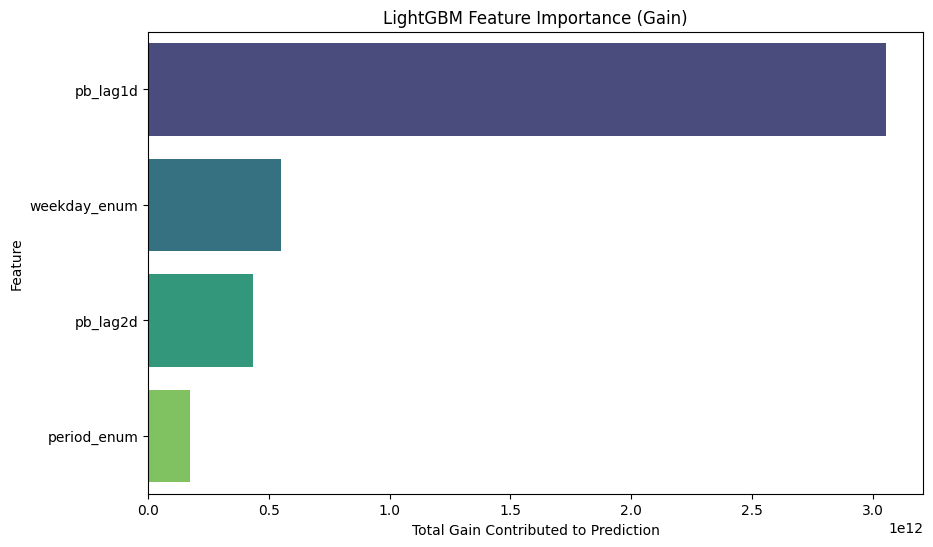

        Feature    Importance
2      pb_lag1d  3.055373e+12
1  weekday_enum  5.504715e+11
3      pb_lag2d  4.336187e+11
0   period_enum  1.756626e+11


In [130]:
import pandas as pd
import seaborn as sns

# 1. Get feature importance (using 'gain' to see contribution to error reduction)
importance = model.feature_importance(importance_type='gain')
feature_names = model.feature_name()

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('LightGBM Feature Importance (Gain)')
plt.xlabel('Total Gain Contributed to Prediction')
plt.show()

# Optional: Print the raw values
print(feature_importance_df)